In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [42]:
df = pd.read_csv("creditcard.csv")
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [43]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [44]:
# seprating the data for analysis
legit = df[df.Class == 0]
fraud = df[df.Class == 1]

In [45]:
print(legit.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


In [46]:
# statistical measures of the data
legit.Amount.describe()


count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [47]:
fraud.Amount.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [48]:
# compare the values for both transactions
df.groupby("Class").mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


In [49]:
legit_sample = legit.sample(n=492)

In [50]:
new_dataset = pd.concat([legit_sample, fraud], axis=0)

In [51]:
new_dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
223787,143523.0,-0.882604,0.713530,0.857932,2.977901,2.026909,-0.571679,0.909430,-0.477739,-1.444529,...,-0.143043,-0.148092,-0.280116,-0.066136,-1.146633,-0.405300,-0.388061,-0.266871,1.00,0
176822,122930.0,1.840117,-0.838783,-0.621520,0.167158,-0.684999,-0.133047,-0.625526,0.054576,1.629287,...,0.206701,0.569180,0.075385,0.602099,-0.184038,0.094569,-0.011505,-0.022577,100.00,0
47397,43199.0,1.188807,0.262403,0.636080,0.642157,-0.380166,-0.688461,0.052860,-0.137018,-0.110118,...,-0.196703,-0.501887,0.193459,0.418395,0.128663,0.100865,-0.007171,0.021281,4.87,0
51051,44769.0,-0.289445,0.519449,1.726145,0.125650,0.582348,0.441076,0.618786,-0.102346,-0.261294,...,-0.115851,-0.082052,0.067021,-0.327605,-1.056145,0.058102,-0.316645,-0.281760,1.98,0
176571,122825.0,-1.238054,-0.389592,2.386836,-1.107162,0.190922,0.203423,0.354894,0.143359,0.268802,...,0.110830,0.098117,-0.094508,-0.502477,0.354859,0.390893,-0.220871,-0.162397,117.71,0


In [52]:
new_dataset.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1
281674,170348.0,1.991976,0.158476,-2.583441,0.408670,1.151147,-0.096695,0.223050,-0.068384,0.577829,...,-0.164350,-0.295135,-0.072173,-0.450261,0.313267,-0.289617,0.002988,-0.015309,42.53,1


In [53]:
new_dataset['Class'].value_counts()

Class
0    492
1    492
Name: count, dtype: int64

In [54]:
new_dataset.groupby("Class").mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,98611.697154,0.022228,-0.081026,0.000442,0.053147,0.013169,-0.088100,0.033540,-0.008152,-0.011751,...,0.048913,-0.009856,-0.026691,-0.028905,-0.007152,-0.036679,0.009959,-0.004308,-0.005299,98.090976
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


In [55]:
# Spliting the data into features and tergets
X = new_dataset.drop(columns='Class', axis=1)
Y = new_dataset ['Class']

In [56]:
print(X)

            Time        V1        V2        V3        V4        V5        V6  \
223787  143523.0 -0.882604  0.713530  0.857932  2.977901  2.026909 -0.571679   
176822  122930.0  1.840117 -0.838783 -0.621520  0.167158 -0.684999 -0.133047   
47397    43199.0  1.188807  0.262403  0.636080  0.642157 -0.380166 -0.688461   
51051    44769.0 -0.289445  0.519449  1.726145  0.125650  0.582348  0.441076   
176571  122825.0 -1.238054 -0.389592  2.386836 -1.107162  0.190922  0.203423   
...          ...       ...       ...       ...       ...       ...       ...   
279863  169142.0 -1.927883  1.125653 -4.518331  1.749293 -1.566487 -2.010494   
280143  169347.0  1.378559  1.289381 -5.004247  1.411850  0.442581 -1.326536   
280149  169351.0 -0.676143  1.126366 -2.213700  0.468308 -1.120541 -0.003346   
281144  169966.0 -3.113832  0.585864 -5.399730  1.817092 -0.840618 -2.943548   
281674  170348.0  1.991976  0.158476 -2.583441  0.408670  1.151147 -0.096695   

              V7        V8        V9  .

In [57]:
print(Y)

223787    0
176822    0
47397     0
51051     0
176571    0
         ..
279863    1
280143    1
280149    1
281144    1
281674    1
Name: Class, Length: 984, dtype: int64


In [58]:
# Split the data into training data and testing data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [59]:
print(X.shape, X_train.shape, X_test.shape )

(984, 30) (787, 30) (197, 30)


In [60]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, Y_train)

Y_pred_lr = lr.predict(X_test)

print("Logistic Regression Results:")
print(classification_report(Y_test, Y_pred_lr))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93        99
           1       0.96      0.90      0.93        98

    accuracy                           0.93       197
   macro avg       0.93      0.93      0.93       197
weighted avg       0.93      0.93      0.93       197



C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Confusion Matrix:
[[95  4]
 [10 88]]


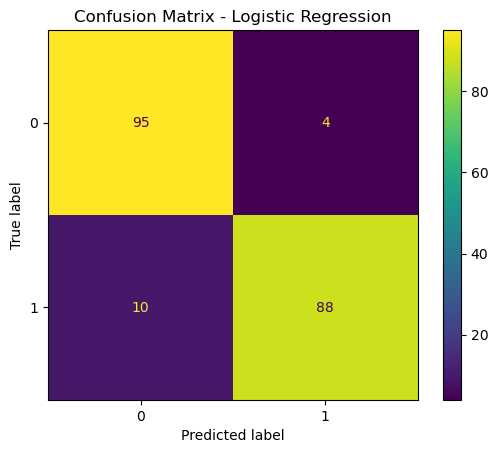

In [61]:
cm = confusion_matrix(Y_test, Y_pred_lr)

print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

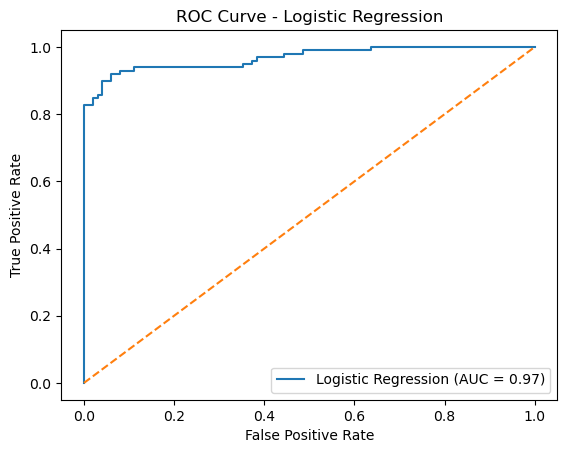

In [62]:
Y_prob_lr = lr.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(Y_test, Y_prob_lr)

# Compute AUC score
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (AUC = %.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.show()

In [63]:
rf = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)

# Train the model
rf.fit(X_train, Y_train)

# Make predictions
Y_pred_rf = rf.predict(X_test)

# Display results
print("Random Forest Results:")
print(classification_report(Y_test, Y_pred_rf))

Random Forest Results:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92        99
           1       0.95      0.88      0.91        98

    accuracy                           0.91       197
   macro avg       0.92      0.91      0.91       197
weighted avg       0.92      0.91      0.91       197



Confusion Matrix - Random Forest:
[[94  5]
 [12 86]]


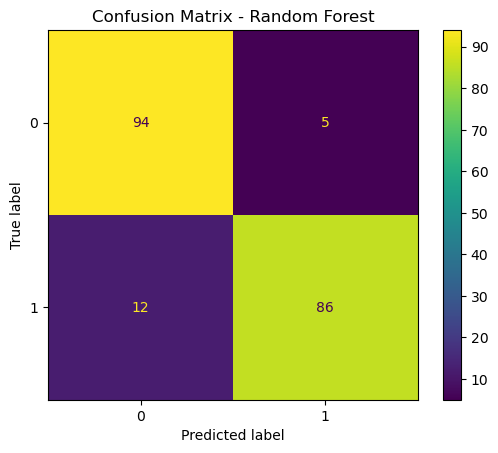

In [64]:
# Create confusion matrix
cm_rf = confusion_matrix(Y_test, Y_pred_rf)

print("Confusion Matrix - Random Forest:")
print(cm_rf)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

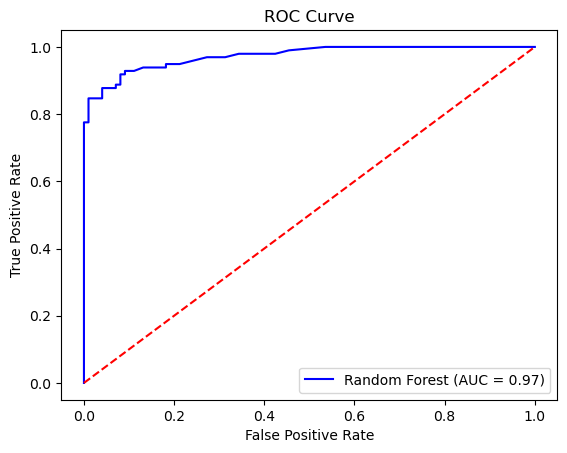

In [65]:
Y_prob_rf = rf.predict_proba(X_test)[:, 1]  # probability for positive class

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(Y_test, Y_prob_rf)

# Compute AUC (Area Under the Curve)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [66]:
# Corss Validation for Logistic Regression
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv = LogisticRegression(max_iter=1000)

lr_cv_scores = cross_val_score(
    lr_cv,
    X,
    Y,
    cv=cv
)

print("Logistic Regression Cross-Validation Scores:", lr_cv_scores)
print("Mean Cross-Validation Score:", lr_cv_scores.mean())

C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i 

Logistic Regression Cross-Validation Scores: [0.93401015 0.95939086 0.94416244 0.95431472 0.89285714]
Mean Cross-Validation Score: 0.9369470630891952


C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [67]:
# Cross validation for Random Forest

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_cv_scores = cross_val_score(
    rf_cv,
    X,
    Y,
    cv=cv
)

print("Random Forest Cross-Validation Scores:", rf_cv_scores)
print("Mean Cross-Validation Score:", rf_cv_scores.mean())

Random Forest Cross-Validation Scores: [0.91370558 0.94923858 0.95431472 0.95431472 0.90816327]
Mean Cross-Validation Score: 0.9359473738734071


In [76]:
import joblib

joblib.dump(lr, "credit_card_model.pkl")

['credit_card_model.pkl']

In [86]:
lr = joblib.load("credit_card_model.pkl")

In [100]:
sample_input = X_test.iloc[0].values.tolist()
pred = lr.predict([sample_input])

print("Prediction:", "Fraud" if pred[0] == 1 else "Legit")


Prediction: Fraud


C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [101]:
sample_input = X_test.iloc[1].values.tolist()
pred = lr.predict([sample_input])

print("Prediction:", "Fraud" if pred[0] == 1 else "Legit")

Prediction: Legit


C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
